In [6]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
#from sklearn import set_config; set_config(display='diagram')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, SelectFromModel, mutual_info_classif

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [7]:
filepath="../data/bank-full.csv"
df = pd.read_csv(filepath, sep=';', header=0)
df[df['y'] == 'yes'].head(50)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
83,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
86,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
87,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
129,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
168,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
270,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
388,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
390,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
446,39,technician,single,unknown,no,45248,yes,no,unknown,6,may,1623,1,-1,0,unknown,yes
457,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes


In [8]:
!pip install statsmodels


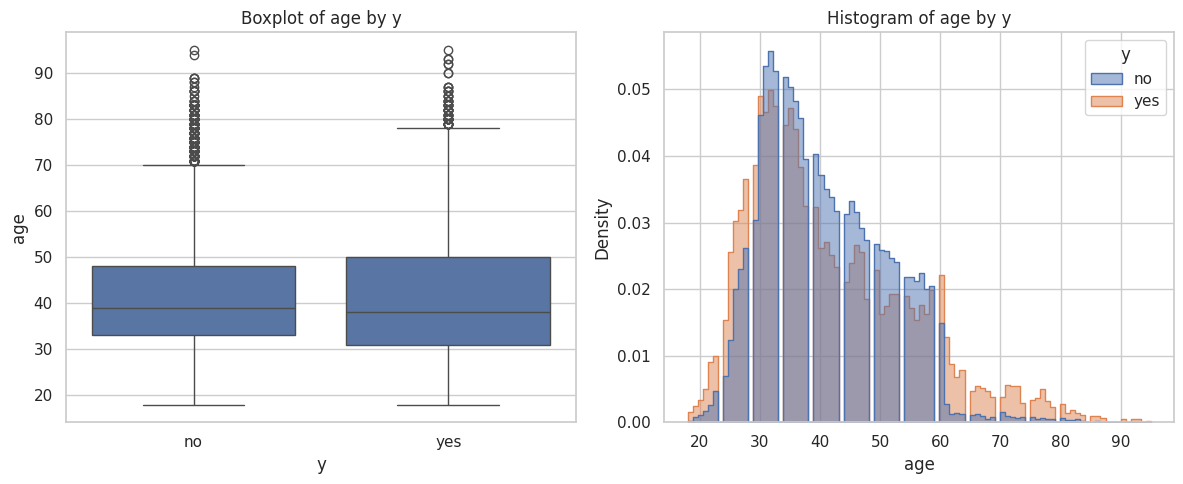

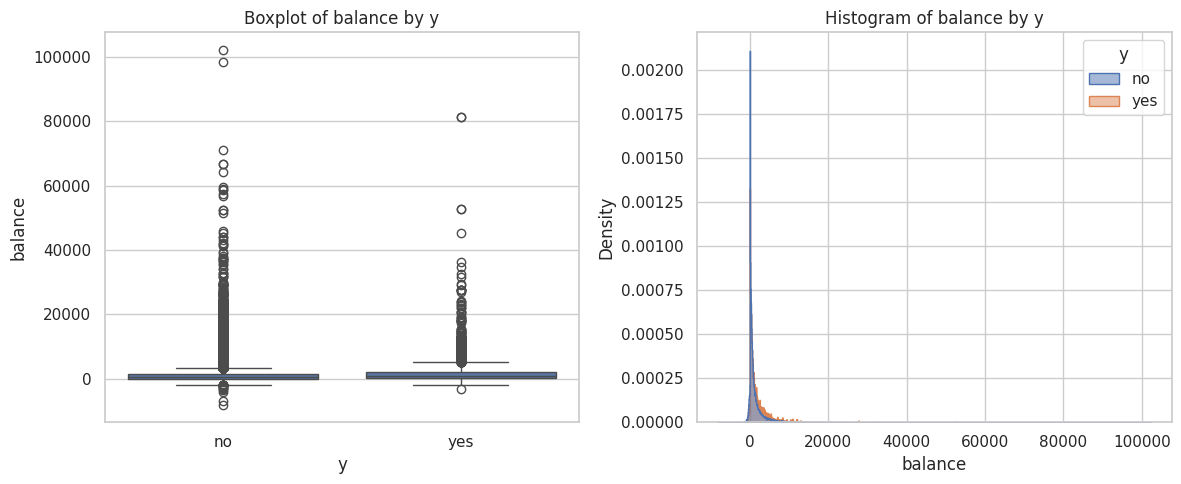

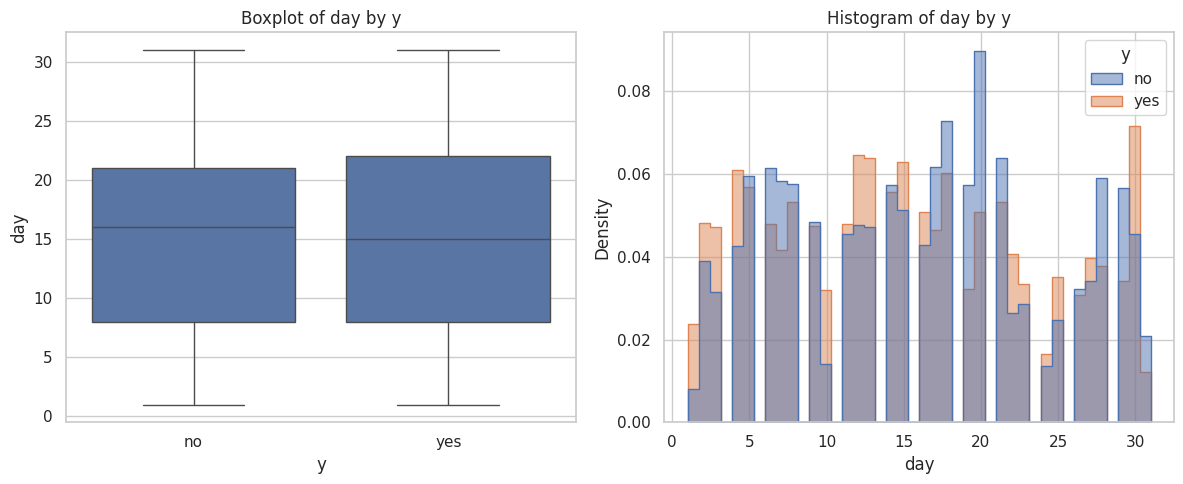

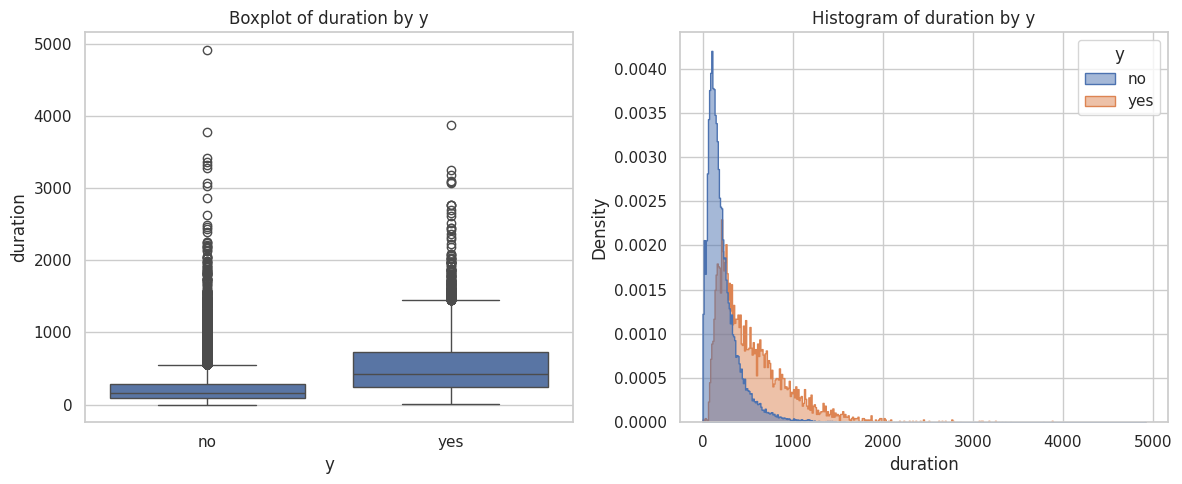

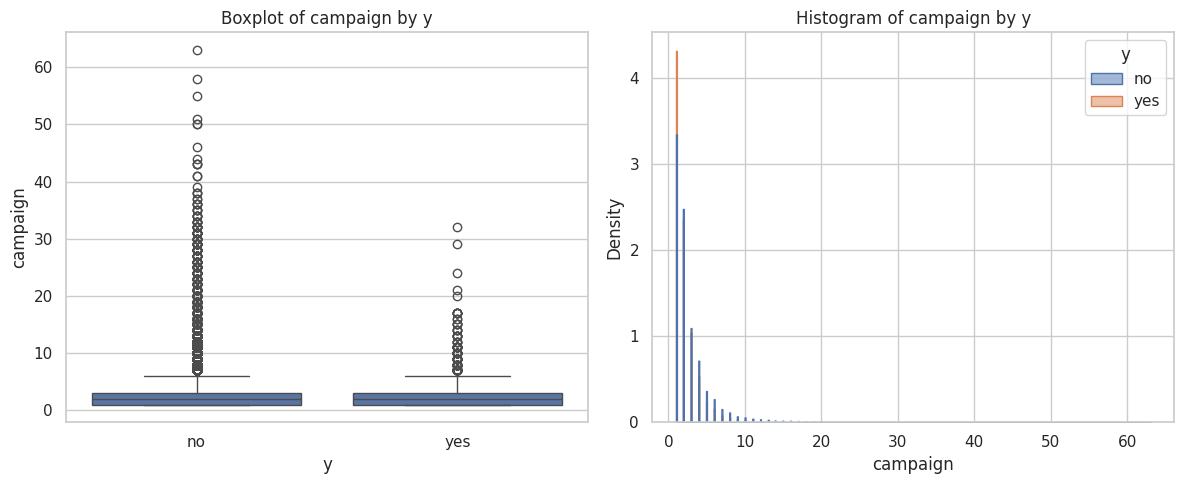

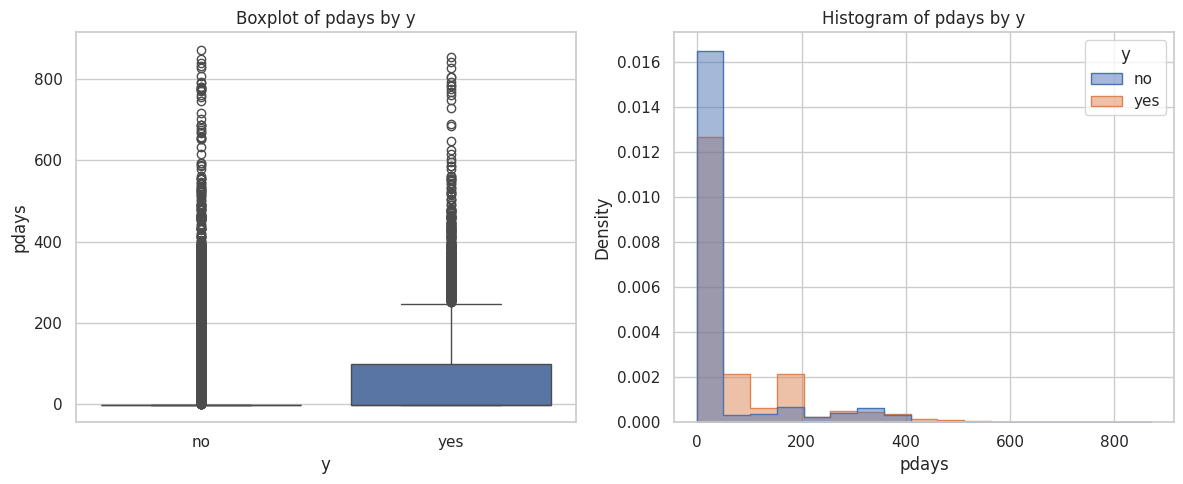

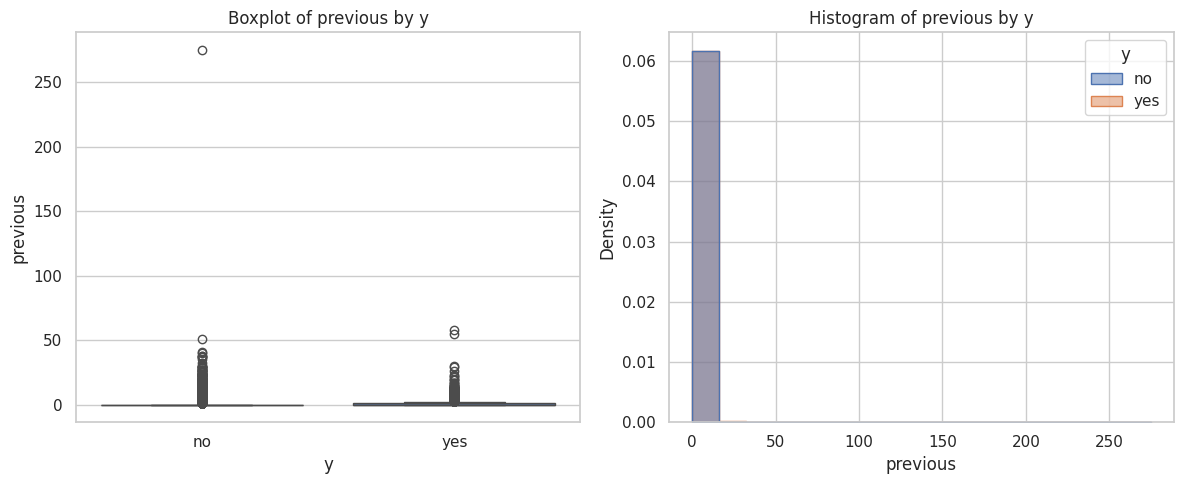

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to visualize
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Set up plotting style
sns.set(style="whitegrid")

for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    # Boxplot split by y
    plt.subplot(1, 2, 1)
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'Boxplot of {col} by y')
    
    # Histogram split by y (with transparency)
    plt.subplot(1, 2, 2)
    sns.histplot(data=df, x=col, hue='y', element='step', stat='density', common_norm=False, alpha=0.5)
    plt.title(f'Histogram of {col} by y')
    
    plt.tight_layout()
    plt.show()


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline  # sklearn's standard pipeline since no SMOTE
import numpy as np
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, classification_report, balanced_accuracy_score
)

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, feature selection (Lasso), classifier (Logistic Regression)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
        threshold='mean'  # keep features with coefficients above average magnitude
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluate - Accuracy, Recall, Precision, F1
print("=== Train Scores ===")
print(f"Accuracy:  {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:    {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:  {f1_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred):.3f}")

# Detailed classification report for test set
print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))




=== Train Scores ===
Accuracy:  0.902
Recall:    0.341
Precision: 0.653
F1 Score:  0.448

=== Validation Scores ===
Accuracy:  0.902
Recall:    0.344
Precision: 0.652
F1 Score:  0.450

=== Test Scores ===
Accuracy:  0.901
Recall:    0.339
Precision: 0.645
F1 Score:  0.445

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.64      0.34      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [11]:
!pip install --upgrade scikit-learn imbalanced-learn




  Using cached scikit_learn-1.7.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.13.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached scikit_learn-1.6.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
Using cached imbalanced_learn-0.13.0-py3-none-any.whl (238 kB)
Using cached scikit_learn-1.6.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2 0/2 [scikit-learn]
  Attempting uninstall: imbalanced-learn━━━━━━━━ 0/2 [scikit-learn]
    Found existing installation: imbalanced-learn 0.10.12 [scikit-learn]
    Uninstalling imbalanced-learn-0.10.1:━━━ 0/2 [scikit-learn]
      Successfully uninstalled imbalanced-learn-0.10.10/2 [scikit-learn]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn][im

In [12]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, SMOTE, feature selection, classifier

#Feature Selection: pick the most important features automatically using a simple Logistic Regression model with L1 regularization (which shrinks less important feature coefficients to zero).

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.
    
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        LogisticRegression(
            penalty='l1', solver='liblinear', max_iter=2000, C=0.5, random_state=42
        ),
        threshold='mean'
    )),
    ('classifier', LogisticRegression(max_iter=2000, C=0.5, random_state=42))
])

# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)


# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


##SMOTE helps when one group is much smaller than the other. By creating synthetic (fake but realistic) examples for the smaller group, SMOTE balances the data so models can learn better and not get biased toward the larger group.


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7b469dcf4dc0>
Traceback (most recent call last):
  File "/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
  File "/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
  File "/home/farah/.pyenv/versions/3.10.6/lib/python3.10/ctypes/__init__.py", line 374, in __init__
    self._handle = _dlopen(self._name, mode)
OSError: dlopen() error


=== Train Scores ===
Accuracy:          0.847
Recall:            0.799
Precision:         0.420
F1 Score:          0.550
Balanced Accuracy: 0.826

=== Validation Scores ===
Accuracy:          0.846
Recall:            0.803
Precision:         0.417
F1 Score:          0.549
Balanced Accuracy: 0.827

=== Test Scores ===
Accuracy:          0.846
Recall:            0.799
Precision:         0.416
F1 Score:          0.547
Balanced Accuracy: 0.825

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.80      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.90      0.85      0.86      9043



Test ROC AUC: 0.901


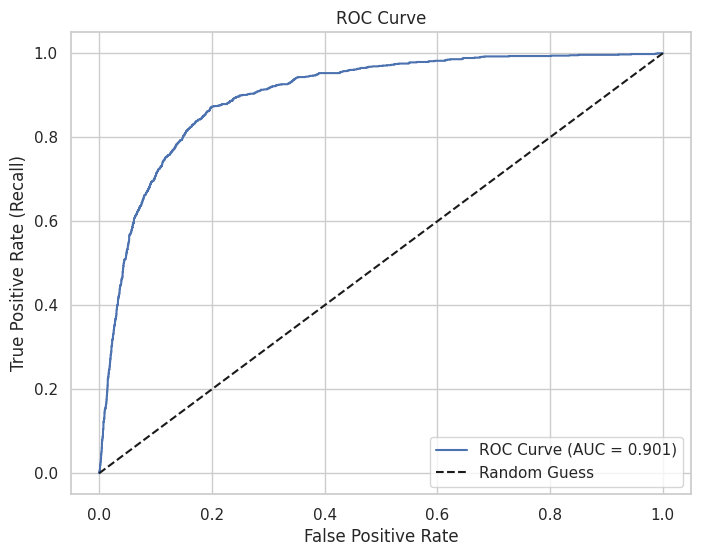

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for positive class (1)
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculate AUC
test_auc = roc_auc_score(y_test, y_test_proba)
print(f"Test ROC AUC: {test_auc:.3f}")

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()
## model's curve staying well above the diagonal and near the top-left corner indicates strong predictive performance.

In [14]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [15]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)


# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)




# Pipeline with SMOTE + XGBoost
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

# Train model
pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)

# Evaluation (same as before)
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [05:52:28] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Train Scores ===
Accuracy:          0.918
Recall:            0.627
Precision:         0.659
F1 Score:          0.643
Balanced Accuracy: 0.792

=== Validation Scores ===
Accuracy:          0.906
Recall:            0.584
Precision:         0.600
F1 Score:          0.592
Balanced Accuracy: 0.766

=== Test Scores ===
Accuracy:          0.905
Recall:            0.564
Precision:         0.602
F1 Score:          0.583
Balanced Accuracy: 0.757

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      7985
           1       0.60      0.56      0.58      1058

    accuracy                           0.91      9043
   macro avg       0.77      0.76      0.76      9043
weighted avg       0.90      0.91      0.90      9043



In [17]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, SMOTE, feature selection, classifier

#Feature Selection: pick the most important features automatically using a simple Logistic Regression model with L1 regularization (which shrinks less important feature coefficients to zero).

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.
    
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        LogisticRegression(
            penalty='l1', solver='saga', max_iter=5000, C=0.5, random_state=42
        ),
        threshold='mean'
    )),
    ('classifier', LogisticRegression(max_iter=5000, C=0.5, random_state=42))
])

# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)

# Get selected features
# Step 1: Get all transformed feature names
num_features_transformed = num_features
cat_features_transformed = list(
    pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
)
all_transformed_features = num_features_transformed + cat_features_transformed

# Step 2: Get boolean mask of selected features
selected_mask = pipeline.named_steps['feature_selection'].get_support()

# Step 3: Apply mask to get selected feature names
selected_features = np.array(all_transformed_features)[selected_mask]

# Step 4: Print selected features
print("\n=== Selected Features ===")
print(selected_features)




# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))



=== Selected Features ===
['duration' 'job_housemaid' 'job_retired' 'job_student' 'default_yes'
 'housing_yes' 'loan_yes' 'contact_unknown' 'month_aug' 'month_dec'
 'month_jan' 'month_jul' 'month_mar' 'month_may' 'month_nov' 'month_oct'
 'month_sep' 'poutcome_success']
=== Train Scores ===
Accuracy:          0.846
Recall:            0.805
Precision:         0.417
F1 Score:          0.550
Balanced Accuracy: 0.828

=== Validation Scores ===
Accuracy:          0.844
Recall:            0.817
Precision:         0.415
F1 Score:          0.550
Balanced Accuracy: 0.832

=== Test Scores ===
Accuracy:          0.848
Recall:            0.811
Precision:         0.422
F1 Score:          0.555
Balanced Accuracy: 0.832

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.56      1058

    accuracy                           0.85      9043
   macro avg       0.70      

In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = [ 'balance', 'duration', 'age']
cat_features = ['job','default','loan','housing','contact','month','poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)

# Pipeline with preprocessing, SMOTE, feature selection, classifier

#Feature Selection: pick the most important features automatically using a simple Logistic Regression model with L1 regularization (which shrinks less important feature coefficients to zero).

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.

#Classifier: a Logistic Regression model that actually learns the relationship between the features and the target.
    
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        penalty='l1',        # L1 regularization
        solver='saga',       # required for L1
        max_iter=5000,
        C=0.5,
        random_state=42
    ))
])


# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)



# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


=== Train Scores ===
Accuracy:          0.846
Recall:            0.814
Precision:         0.419
F1 Score:          0.553
Balanced Accuracy: 0.832

=== Validation Scores ===
Accuracy:          0.843
Recall:            0.808
Precision:         0.412
F1 Score:          0.546
Balanced Accuracy: 0.828

=== Test Scores ===
Accuracy:          0.847
Recall:            0.806
Precision:         0.419
F1 Score:          0.552
Balanced Accuracy: 0.829

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.69      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



In [22]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = [ 'balance', 'duration', 'age']
cat_features = ['job','default','loan','housing','contact','month','poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        objective='binary:logistic',  # binary classification
        eval_metric='logloss',        # evaluation metric
        use_label_encoder=False,
        reg_alpha=0.5,                # L1 regularization
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        random_state=42
    ))
])

# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)



# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [06:21:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Train Scores ===
Accuracy:          0.902
Recall:            0.713
Precision:         0.566
F1 Score:          0.631
Balanced Accuracy: 0.820

=== Validation Scores ===
Accuracy:          0.890
Recall:            0.664
Precision:         0.522
F1 Score:          0.585
Balanced Accuracy: 0.792

=== Test Scores ===
Accuracy:          0.890
Recall:            0.658
Precision:         0.525
F1 Score:          0.584
Balanced Accuracy: 0.790

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.95      0.92      0.94      7985
           1       0.53      0.66      0.58      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.79      0.76      9043
weighted avg       0.90      0.89      0.90      9043



In [23]:
from collections import Counter
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]  # majority/minority ratio


In [26]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score, precision_score, f1_score, classification_report
)
import numpy as np

# Prepare target and features
y = df['y'].map({'no': 0, 'yes': 1})
X = df.drop(columns=['y'])

num_features = [ 'balance', 'duration', 'age']
cat_features = ['job','default','loan','housing','contact','month','poutcome']

categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

# Train / val / test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42
)


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        reg_alpha=2,       # L1 regularization ↑ (default 0)
        reg_lambda=5,      # L2 regularization ↑ (default 1)
        random_state=42
    ))
])

# Train model

#runs all steps: preprocess data, balance classes, select important features, and then train the classifier on the training data.

pipeline.fit(X_train, y_train)



# Predictions
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Evaluate - Accuracy, Recall, Precision, F1, Balanced Accuracy
print("=== Train Scores ===")
print(f"Accuracy:          {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Recall:            {recall_score(y_train, y_train_pred):.3f}")
print(f"Precision:         {precision_score(y_train, y_train_pred):.3f}")
print(f"F1 Score:          {f1_score(y_train, y_train_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_train, y_train_pred):.3f}")

print("\n=== Validation Scores ===")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.3f}")
print(f"Recall:            {recall_score(y_val, y_val_pred):.3f}")
print(f"Precision:         {precision_score(y_val, y_val_pred):.3f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.3f}")

print("\n=== Test Scores ===")
print(f"Accuracy:          {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Recall:            {recall_score(y_test, y_test_pred):.3f}")
print(f"Precision:         {precision_score(y_test, y_test_pred):.3f}")
print(f"F1 Score:          {f1_score(y_test, y_test_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_test_pred):.3f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


/home/farah/.pyenv/versions/3.10.6/envs/lewagon_cust_targeting/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [06:31:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Train Scores ===
Accuracy:          0.898
Recall:            0.698
Precision:         0.549
F1 Score:          0.615
Balanced Accuracy: 0.811

=== Validation Scores ===
Accuracy:          0.890
Recall:            0.681
Precision:         0.521
F1 Score:          0.591
Balanced Accuracy: 0.799

=== Test Scores ===
Accuracy:          0.891
Recall:            0.675
Precision:         0.526
F1 Score:          0.591
Balanced Accuracy: 0.797

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      7985
           1       0.53      0.67      0.59      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.80      0.76      9043
weighted avg       0.91      0.89      0.90      9043

